In [1]:
def classify_difficulty(q):
    if q in [1]:
        return "Hard"
    elif q in [2]:
        return "Medium"
    elif q in [3, 4]:
        return "Easy"
    else:
        return "Unknown"


In [4]:
import pandas as pd

# Load your Excel file
df = pd.read_excel("predicted_masks\segmentation_report.xlsx", sheet_name=None)  # Load all sheets

# Process all sheets
for sheet_name, data in df.items():
    # Split Segmentation_quality into numeric score and label (if it exists)
    if "segmentation_quality" in data.columns:
        split_cols = data["segmentation_quality"].astype(str).str.split("-", n=1, expand=True)
        # print(split_cols)
        data["quality_score"] = split_cols[0].str.strip().astype(float)  # numeric part
        data["quality_label"] = split_cols[1].str.strip() if split_cols.shape[1] > 1 else None
        df[sheet_name] = data

# Save back to a new Excel file
with pd.ExcelWriter("predicted_masks\segmentation_report_split.xlsx", engine="openpyxl") as writer:
    for sheet_name, data in df.items():
        data.to_excel(writer, sheet_name=sheet_name, index=False)

print("✅ Saved cleaned version to segmentation_report_split.xlsx")


✅ Saved cleaned version to segmentation_report_split.xlsx


C:\Users\AI_Training\anaconda3\envs\my_cuda_env\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [6]:
df = pd.read_excel("predicted_masks/segmentation_report_split.xlsx", sheet_name=None)

for sheet_name, data in df.items():
    if "quality_score" in data.columns:
        # Define difficulty mapping logic
        data["difficulty_level"] = data["quality_score"].apply(
            lambda x: (
                "Hard" if x <= 1.5 else
                "Medium" if x <= 2.5 else
                "Easy" if x <= 3.5 else
                "Very Easy"
            )
        )
        df[sheet_name] = data

# Save updated version
with pd.ExcelWriter("predicted_masks/segmentation_report_difficulty.xlsx", engine="openpyxl") as writer:
    for sheet_name, data in df.items():
        data.to_excel(writer, sheet_name=sheet_name, index=False)
df_all = pd.concat(df.values(), ignore_index=True)

print(df_all.head())
print(df_all["difficulty_level"].value_counts())

  image_id                                      relative_path material  \
0    1.png  Training samples\ALUM\2019-0505 Macrosections\...     ALUM   
1   11.png  Training samples\ALUM\2019-0505 Macrosections\...     ALUM   
2   12.png  Training samples\ALUM\2019-0505 Macrosections\...     ALUM   
3   13.png  Training samples\ALUM\2019-0505 Macrosections\...     ALUM   
4   14.png  Training samples\ALUM\2019-0505 Macrosections\...     ALUM   

                 subfolder_path segmentation_quality failure_type  notes  \
0  ALUM/2019-0505 Macrosections        4 - Excellent  No Failiure    NaN   
1  ALUM/2019-0505 Macrosections        4 - Excellent  No Failiure    NaN   
2  ALUM/2019-0505 Macrosections        4 - Excellent  No Failiure    NaN   
3  ALUM/2019-0505 Macrosections        4 - Excellent  No Failiure    NaN   
4  ALUM/2019-0505 Macrosections        4 - Excellent  No Failiure    NaN   

   include_in_train  include_in_test  quality_score quality_label  \
0               NaN          

In [6]:
summary = []

for sheet_name, data in df.items():
    if "difficulty_level" in data.columns:
        stats = (
            data.groupby("difficulty_level")
            .size()
            .reset_index(name="count")
            .assign(material=sheet_name)
        )
        summary.append(stats)

summary_df = pd.concat(summary, ignore_index=True)
print(summary_df)

# Save summary for quick inspection
summary_df.to_excel("predicted_masks/segmentation_difficulty_summary.xlsx", index=False)
print("📊 Summary saved to segmentation_difficulty_summary.xlsx")


  difficulty_level  count          material
0             Easy     42  Training samples
1             Hard    173  Training samples
2           Medium     28  Training samples
3        Very Easy    169  Training samples
📊 Summary saved to segmentation_difficulty_summary.xlsx


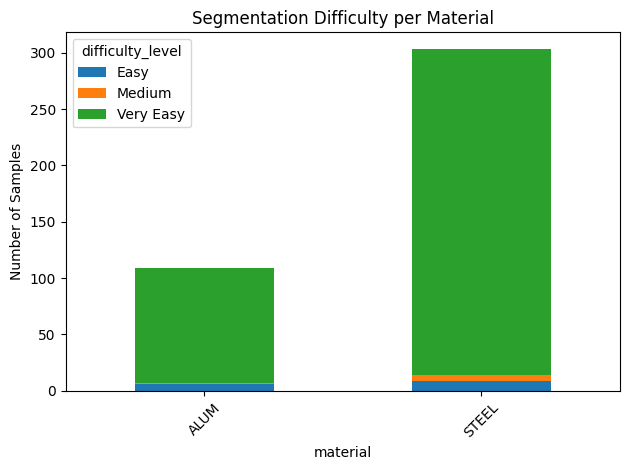

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
df_all.groupby(["material", "difficulty_level"]).size().unstack().plot(kind="bar", stacked=True)
plt.title("Segmentation Difficulty per Material")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import shutil
import os
df_filtered = df_all[df_all["difficulty_level"].isin(["Hard", "Medium"])]

# Destination folder
dest_folder = "predicted_masks/hard_medium_images"
os.makedirs(dest_folder, exist_ok=True)

base_folder = "predicted_masks/images"

# Copy images to the new folder
for rel_path in df_filtered["relative_path"]:
    # Construct full path
    source_path = os.path.join(base_folder, *rel_path.split("\\"))  # Handles Windows-style backslashes
    if os.path.exists(source_path):
        shutil.copy(source_path, dest_folder)
    else:
        print(f"Warning: file not found {source_path}")

print(f"Copied {len(df_filtered)} images to {dest_folder}")

Copied 201 images to predicted_masks/hard_medium_images


In [20]:
import os
from PIL import Image

# Folder containing Hard & Medium images
source_folder = "predicted_masks/hard_medium_images"

# Optional: output folder (if you want to keep originals)
output_folder = "predicted_masks/hard_medium_images_png"
os.makedirs(output_folder, exist_ok=True)

# Walk through all files in the folder
for root, dirs, files in os.walk(source_folder):
    # Create corresponding folder structure in output folder
    relative_path = os.path.relpath(root, source_folder)
    save_dir = os.path.join(output_folder, relative_path)
    os.makedirs(save_dir, exist_ok=True)

    for file in files:
        if file.lower().endswith(".tif") or file.lower().endswith(".tiff"):
            tif_path = os.path.join(root, file)
            png_path = os.path.join(save_dir, os.path.splitext(file)[0] + ".png")

            # Open and save as PNG
            with Image.open(tif_path) as img:
                img.save(png_path, format="PNG")

            print(f"Converted {tif_path} → {png_path}")

print("All .tif images converted to .png!")


Converted predicted_masks/hard_medium_images\13 e.tif → predicted_masks/hard_medium_images_png\.\13 e.png
Converted predicted_masks/hard_medium_images\14 e.tif → predicted_masks/hard_medium_images_png\.\14 e.png
Converted predicted_masks/hard_medium_images\15 e.tif → predicted_masks/hard_medium_images_png\.\15 e.png
Converted predicted_masks/hard_medium_images\16 e.tif → predicted_masks/hard_medium_images_png\.\16 e.png
Converted predicted_masks/hard_medium_images\17 e.tif → predicted_masks/hard_medium_images_png\.\17 e.png
Converted predicted_masks/hard_medium_images\18 e.tif → predicted_masks/hard_medium_images_png\.\18 e.png
Converted predicted_masks/hard_medium_images\22A e.tif → predicted_masks/hard_medium_images_png\.\22A e.png
Converted predicted_masks/hard_medium_images\22B e.tif → predicted_masks/hard_medium_images_png\.\22B e.png
Converted predicted_masks/hard_medium_images\23A e.tif → predicted_masks/hard_medium_images_png\.\23A e.png
Converted predicted_masks/hard_medium_im